In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

## 1.读数据

In [102]:
train = pd.read_csv('cs-training.csv')
train.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [103]:
#分组
X = train.drop('SeriousDlqin2yrs', axis=1)
y = train['SeriousDlqin2yrs']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

## 2.清洗数据

In [104]:
X_train = X_train.drop('Unnamed: 0',axis=1) #删除无用列
X_train.isnull().sum() 

RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           20729
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2734
dtype: int64

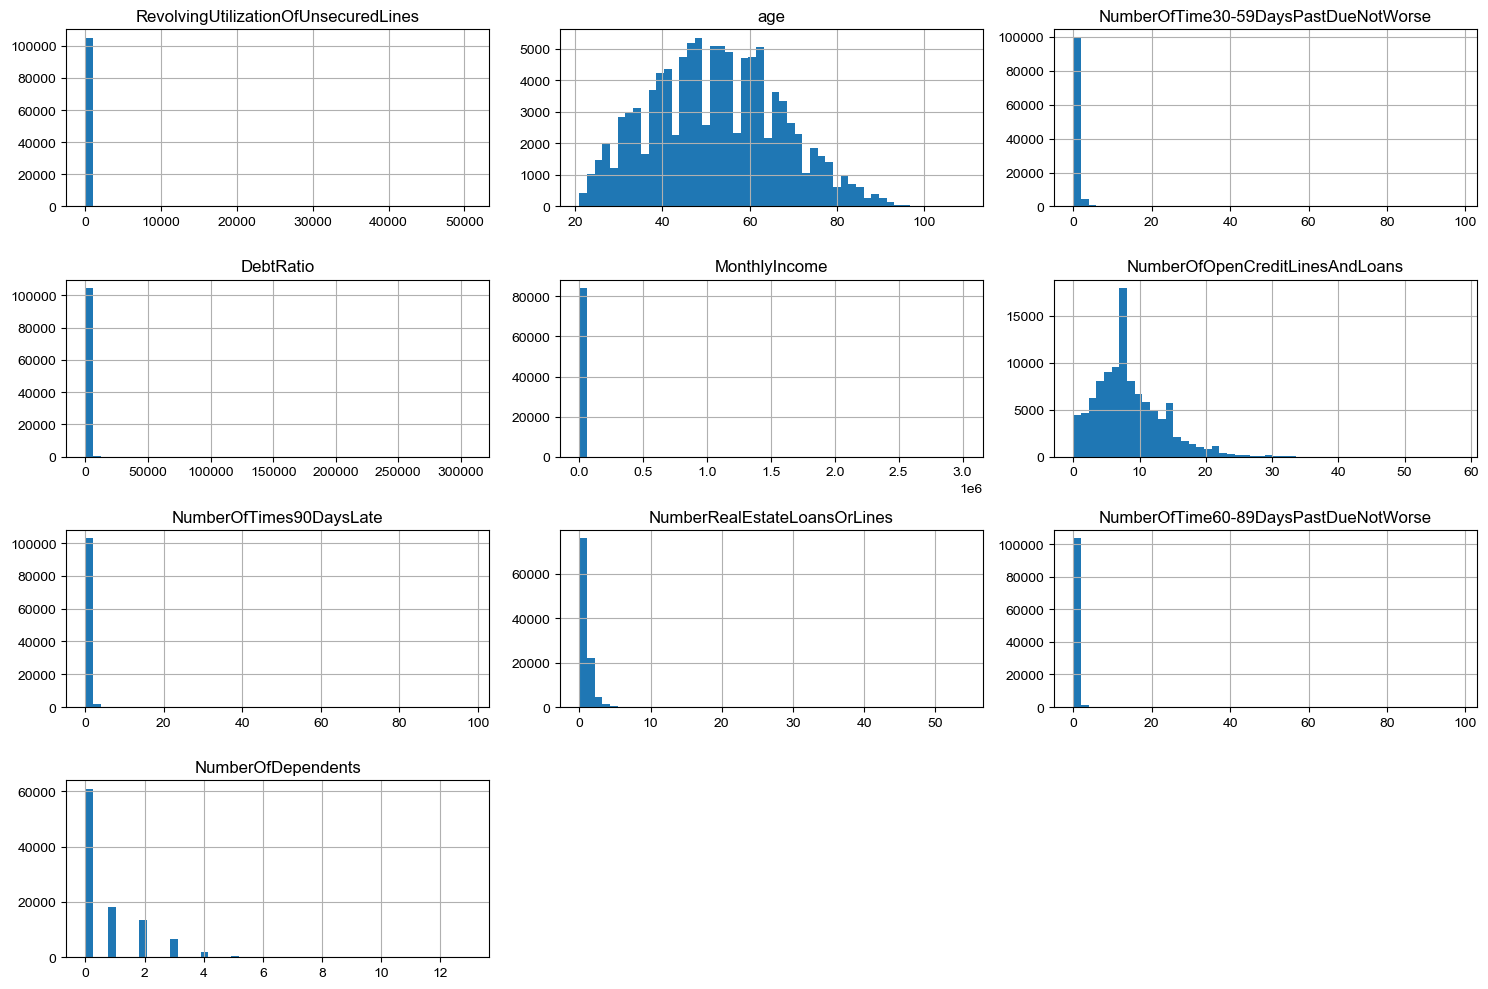

In [105]:
X_train.hist(bins=50,figsize=(15,10))
plt.tight_layout()
plt.show()

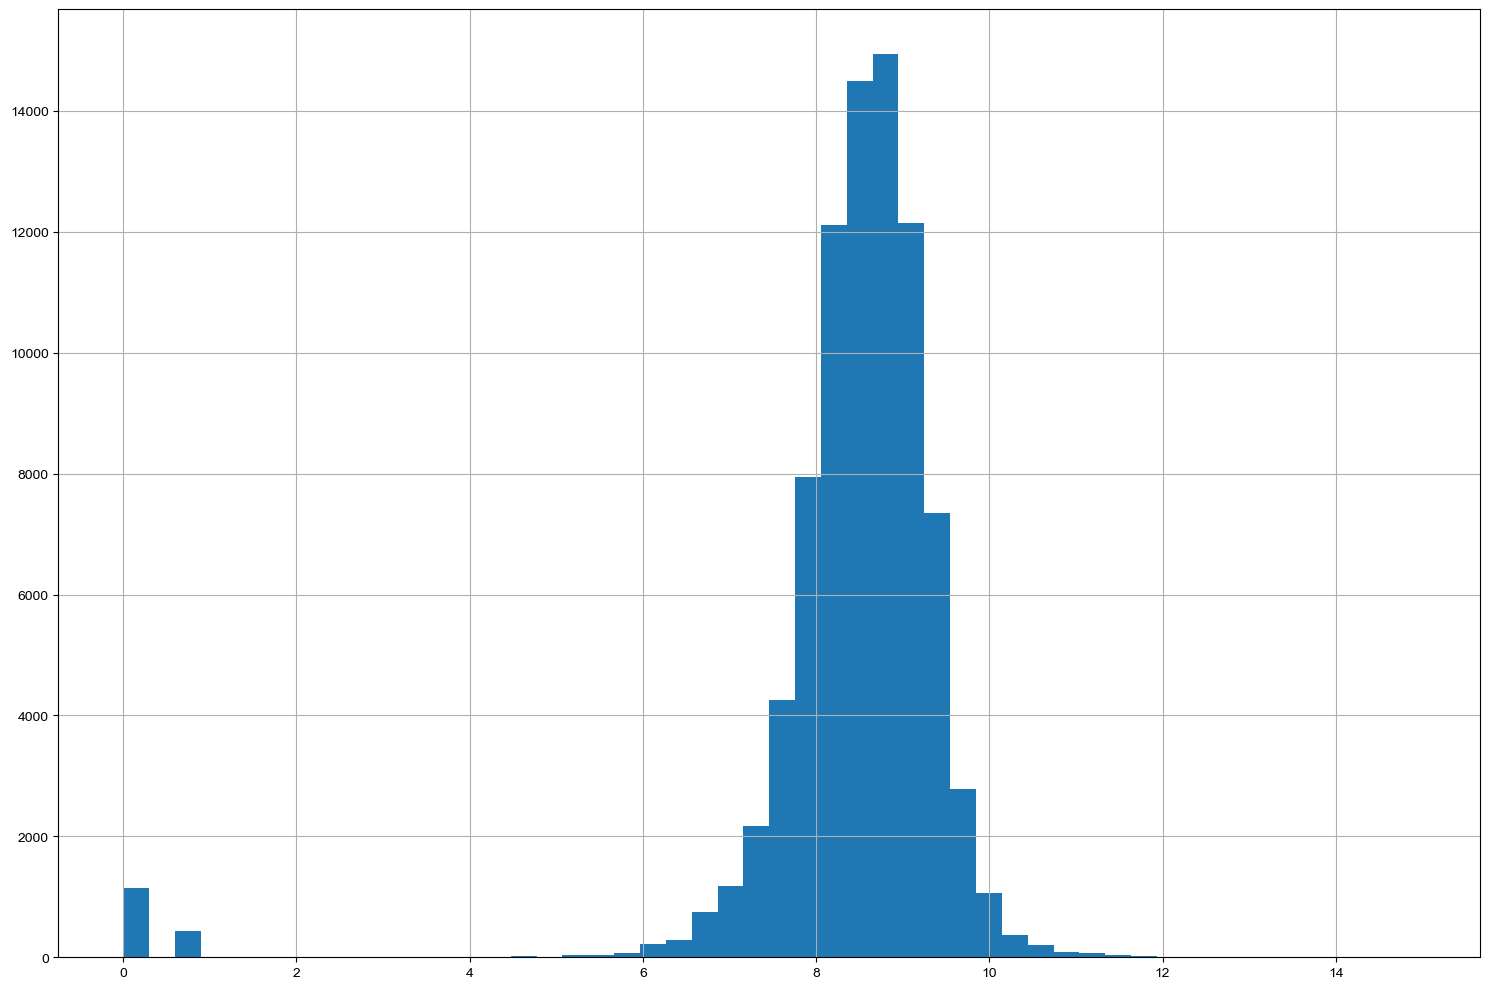

In [106]:
fig, ax = plt.subplots(figsize=(15, 10))
np.log1p(X_train['MonthlyIncome']).hist(bins=50, ax=ax)
plt.tight_layout()
plt.show()

In [107]:
#处理'RevolvingUtilizationOfUnsecuredLines'
X_train['RevolvingUtilizationOfUnsecuredLines'] = X_train['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)
#处理'age'
X_train.loc[X_train['age']<18,'age'] = np.nan
X_train['age'] = X_train['age'].fillna(X_train['age'].median())
#处理'NumberOfTime30-59DaysPastDueNotWorse'
X_train['NumberOfTime30-59DaysPastDueNotWorse'] = X_train['NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=21)
X_train['NumberOfTime30-59DaysPastDueNotWorse'] = X_train['NumberOfTime30-59DaysPastDueNotWorse'].replace(21,np.nan)
X_train['NumberOfTime30-59DaysPastDueNotWorse'] = X_train['NumberOfTime30-59DaysPastDueNotWorse'].fillna(X_train['NumberOfTime30-59DaysPastDueNotWorse'].median())
#处理'DebtRatio'
X_train['DebtRatio'] = X_train['DebtRatio'].clip(upper=1)
#处理'MonthlyIncome'
X_train['MonthlyIncome_miss'] = X_train['MonthlyIncome'].isnull().astype('int')
X_train.loc[X_train['MonthlyIncome'].isnull(),'MonthlyIncome'] = X_train['MonthlyIncome'].median()
#处理'NumberOfTimes90DaysLate'
X_train.loc[X_train['NumberOfTimes90DaysLate']>18,'NumberOfTimes90DaysLate'] = X_train['NumberOfTimes90DaysLate'].median()
#处理'NumberOfTime60-89DaysPastDueNotWorse'
X_train.loc[X_train['NumberOfTime60-89DaysPastDueNotWorse']>18,'NumberOfTime60-89DaysPastDueNotWorse'] = X_train['NumberOfTime60-89DaysPastDueNotWorse'].median()
#处理'NumberOfDependents'
X_train.loc[X_train['NumberOfDependents'].isnull(),'NumberOfDependents'] = X_train['NumberOfDependents'].median()

## 3.EDA

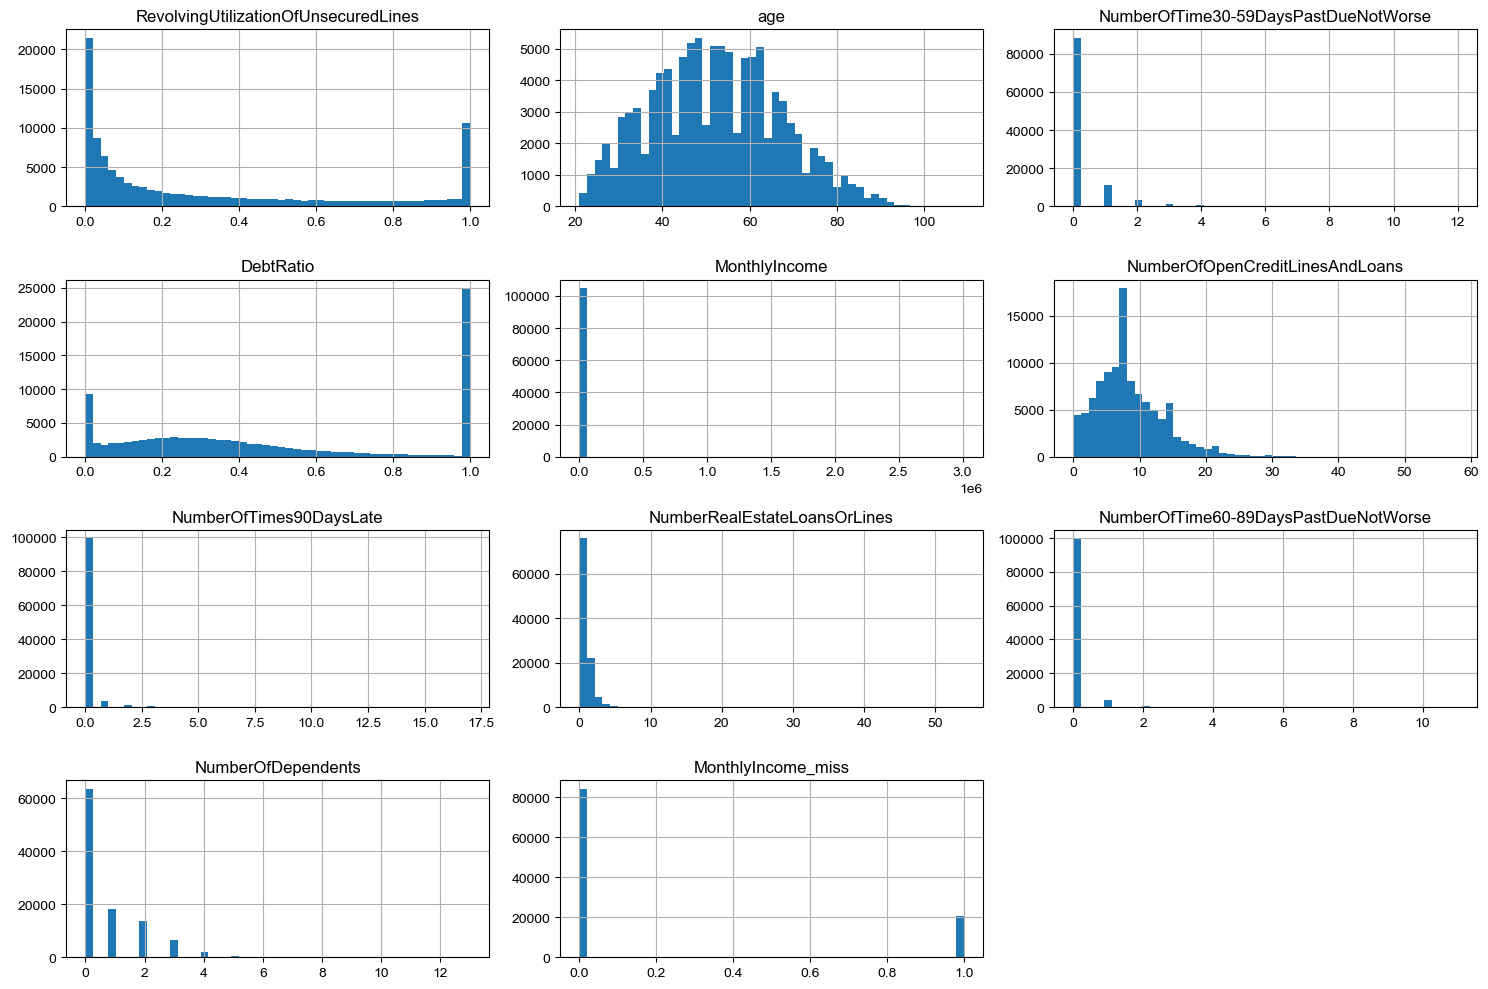

In [108]:
X_train.hist(bins=50,figsize=(15,10))
plt.tight_layout()
plt.show()

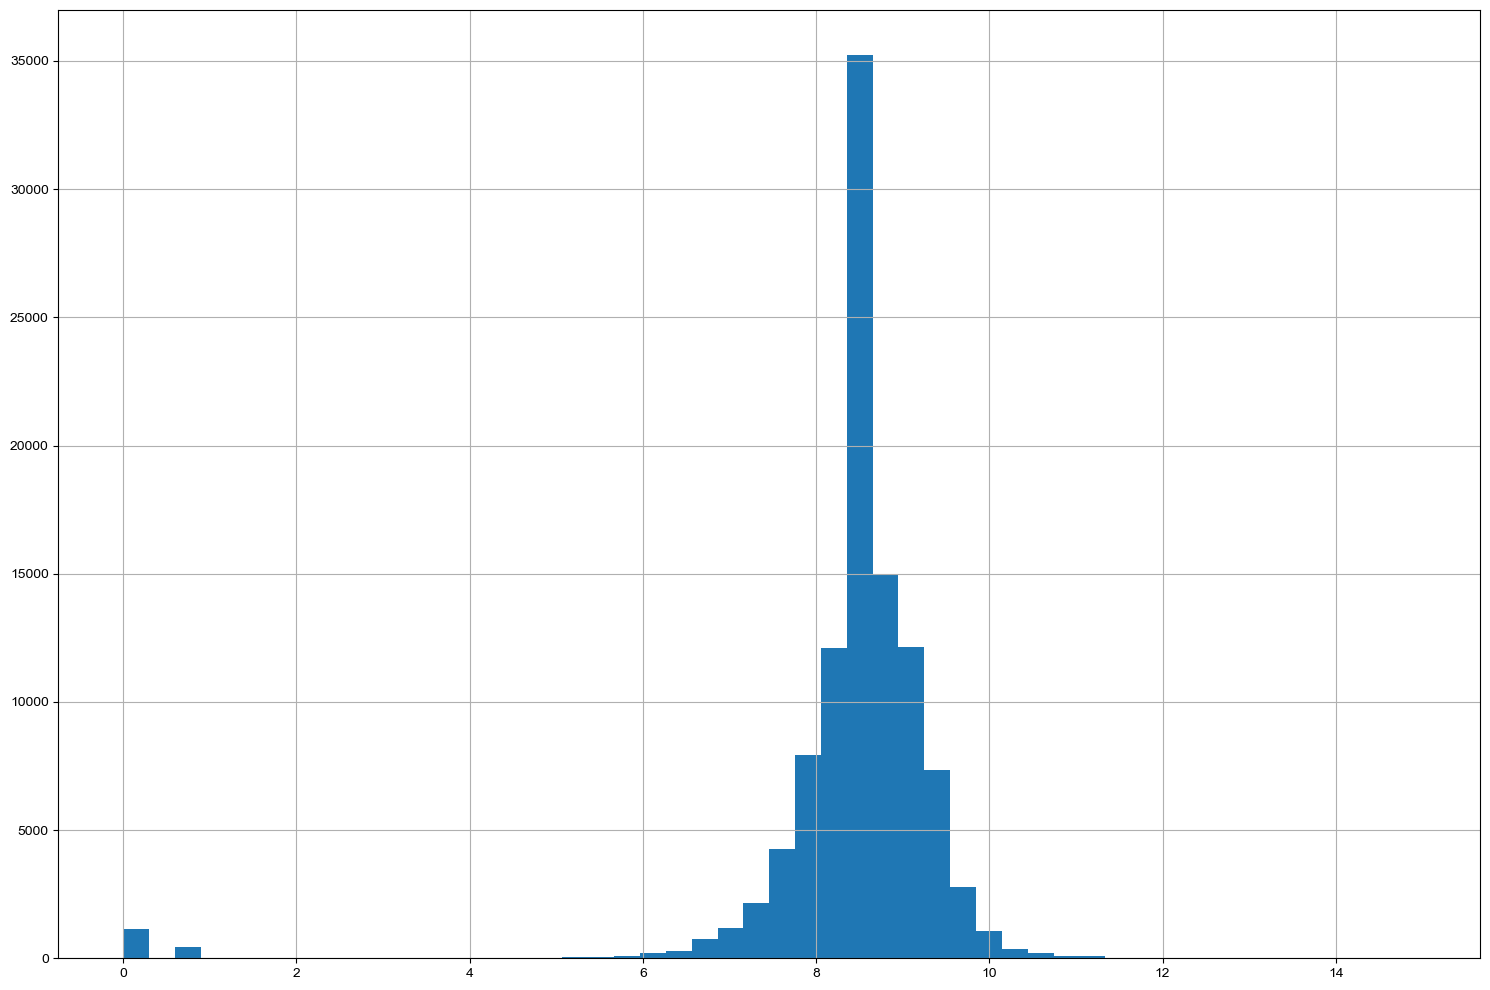

In [109]:
fig, ax = plt.subplots(figsize=(15, 10))
np.log1p(X_train['MonthlyIncome']).hist(bins=50, ax=ax)
plt.tight_layout()
plt.show()

In [110]:
df = pd.concat([X_train,y_train],axis=1)
df.groupby('SeriousDlqin2yrs').mean()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_miss
SeriousDlqin2yrs,,,,,,,,,,,
0,0.293714,52.766217,0.196990,0.464260,6476.576618,8.498734,0.049595,1.020816,0.041244,0.725320,0.199716
1,0.680523,45.826852,0.943798,0.497267,5599.252484,7.885609,0.665200,0.984104,0.384615,0.918677,0.165484


## 4.特征工程

In [111]:
#WOE与IV函数
def calc_woe_iv(df,feature,target,which='qwq'):
    df = df.copy()
    #分箱
    if feature.startswith('NumberOfTime'):
        bins=[0,1,2,3,4,5,6,7,8,9,100]
        df['bin'] = pd.cut(df[feature],bins,right=False)
    else:
        df['bin'] = pd.qcut(df[feature],10,duplicates='drop')
    #计算好坏
    good_total = df.loc[df[target]==0,target].count()
    bad_total = df.loc[df[target]==1,target].count()
    #分组 
    df_bad = df.groupby('bin')[target].sum()
    df_good = (df.groupby('bin')[target].count()- df_bad)
    #WOE/IV
    result = pd.DataFrame({'good': df_good, 'bad': df_bad})
    result['WOE'] = np.log(((df_good+0.5)/good_total)/((df_bad+0.5)/bad_total))
    IV = sum(((result['good']/good_total)-(result['bad']/bad_total))*result['WOE'])
    if which == 'IV':
        return IV
    else:
        return result,df

In [112]:
#查看IV大小,选取前五大的进行回归
IV_Series = {}
for column in X_train.columns:
    IV_Series[column] = calc_woe_iv(df,column,'SeriousDlqin2yrs',which='IV')
pd.Series(IV_Series).sort_values(ascending=False)

RevolvingUtilizationOfUnsecuredLines    1.097721
NumberOfTimes90DaysLate                 0.839329
NumberOfTime30-59DaysPastDueNotWorse    0.692243
NumberOfTime60-89DaysPastDueNotWorse    0.541038
age                                     0.265525
MonthlyIncome                           0.069322
NumberOfOpenCreditLinesAndLoans         0.064381
DebtRatio                               0.028621
NumberOfDependents                      0.022183
NumberRealEstateLoansOrLines            0.010219
MonthlyIncome_miss                      0.000000
dtype: float64

In [113]:
#WOE代替原值
pd_train = pd.DataFrame()
woe_maps = {}
targe_woe=['RevolvingUtilizationOfUnsecuredLines','NumberOfTimes90DaysLate','NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','age']
for column in targe_woe:
    x,woe_match = calc_woe_iv(df,column,'SeriousDlqin2yrs')
    woe_maps[column] = x['WOE']
    pd_train[column] = woe_match['bin'].map(x['WOE'])

In [114]:
#检查共线性 (VIF)
from sklearn.linear_model import LinearRegression
def calculate_vif_manual(df):
    for feature_idx in df.columns:
        X = df.drop(feature_idx,axis=1)
        y = df[feature_idx]
        lr = LinearRegression()
        lr.fit(X,y)
        r_squared = lr.score(X,y)
        vif = 1/(1-r_squared)
        print(f"变量:{feature_idx},vif:{vif}")
calculate_vif_manual(pd_train)

变量:RevolvingUtilizationOfUnsecuredLines,vif:1.212778036099559
变量:NumberOfTimes90DaysLate,vif:1.1897417616409711
变量:NumberOfTime30-59DaysPastDueNotWorse,vif:1.1662938409271615
变量:NumberOfTime60-89DaysPastDueNotWorse,vif:1.1780195273457528
变量:age,vif:1.091676680522519


In [115]:
#协方差
pd_train.corr()

,RevolvingUtilizationOfUnsecuredLines,NumberOfTimes90DaysLate,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,age
RevolvingUtilizationOfUnsecuredLines,1.000000,0.273427,0.248176,0.199680,0.287527
NumberOfTimes90DaysLate,0.273427,1.000000,0.256806,0.308233,0.097911
NumberOfTime30-59DaysPastDueNotWorse,0.248176,0.256806,1.000000,0.294620,0.100067
NumberOfTime60-89DaysPastDueNotWorse,0.199680,0.308233,0.294620,1.000000,0.081752
age,0.287527,0.097911,0.100067,0.081752,1.000000


In [116]:
#测试集转化WOE
pd_test = pd.DataFrame()
for column in targe_woe:
    if column.startswith('NumberOfTime'):
        bins = [0,1,2,3,4,5,6,7,8,9,100]
        pd_test[column] = pd.cut(X_test[column], bins, right=False).map(woe_maps[column])
    else:
        edges = [-np.inf] + [iv.left for iv in woe_maps[column].index[1:]] + [np.inf]
        new_keys = [pd.Interval(edges[i], edges[i+1]) for i in range(len(edges)-1)]
        woe_map_new = dict(zip(new_keys, woe_maps[column].values))
        pd_test[column] = pd.cut(X_test[column], bins=edges).map(woe_map_new)

## 5.回归模型

In [117]:
#回归模型
lr = LogisticRegression(C=1, l1_ratio=0, solver='lbfgs', max_iter=1000)
lr.fit(pd_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[[-0.6533025  -0.53622742 -0.54318237 -0.41164891 -0.47185907]]
[-2.60779636]


## 6.模型评估

In [118]:
# AUC
y_pred_prob = lr.predict_proba(pd_test)[:, 1]
AUC = roc_auc_score(y_test,y_pred_prob)
print(f'AUC: {AUC:.4f}')

AUC: 0.8523


## 7.评分卡转换

### 7.1计算分数

In [119]:
#基础设定
BASE_SCORE = 600
PDO = 20
BASE_ODDS = 1/20
#计算映射式
factor = PDO / np.log(2)
offset = BASE_SCORE - factor*np.log(BASE_ODDS)
#带入回归式
coefs = lr.coef_[0]
intercept = lr.intercept_[0]
feature_names = pd_train.columns.tolist()
base_score = offset - factor*intercept
print(f'基础分:{base_score:.2f}')
print()

print('各变量得分权重:')
k_dict = {}
for feat, coef in zip(feature_names, coefs):
    weight = -coef * factor
    k_dict[feat] = weight
    print(f'{feat}: {weight:.4f}')

基础分:761.68

各变量得分权重:
RevolvingUtilizationOfUnsecuredLines: 18.8503
NumberOfTimes90DaysLate: 15.4723
NumberOfTime30-59DaysPastDueNotWorse: 15.6729
NumberOfTime60-89DaysPastDueNotWorse: 11.8777
age: 13.6150


In [120]:
dict_score = {}
for column in targe_woe:
    result, _ = calc_woe_iv(df, column, 'SeriousDlqin2yrs')
    score_series = result['WOE'] * k_dict[column]
    dict_score[column] = pd.DataFrame({'WOE': result['WOE'], 'score': score_series})

In [ ]:
#计算最终分数
#pd_train_score
pd_train_score = pd.DataFrame()
targe_woe=['RevolvingUtilizationOfUnsecuredLines','NumberOfTimes90DaysLate','NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','age']
for column in targe_woe:
    _,woe_match = calc_woe_iv(df,column,'SeriousDlqin2yrs')
    pd_train_score[column] = woe_match['bin'].map(dict_score[column]['score'])

pd_train_score['Score'] = pd_train_score[targe_woe].sum(axis=1)+base_score
pd_train_score = pd_train_score.iloc[:,[5,0,1,2,3,4]]
pd_train_score

,Score,RevolvingUtilizationOfUnsecuredLines,NumberOfTimes90DaysLate,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,age
27822,791.145294,12.281452,5.73949,7.989599,3.153468,0.301285
85202,737.675365,-19.164106,5.73949,-14.034773,3.153468,0.301285
42217,792.678730,19.520188,5.73949,7.989599,3.153468,-5.404015
119958,817.153779,29.885200,5.73949,7.989599,3.153468,8.706023
37678,806.495244,19.226665,5.73949,7.989599,3.153468,8.706023
...,...,...,...,...,...,...
119879,811.221794,19.520188,5.73949,7.989599,3.153468,13.139048
103694,789.197422,19.520188,5.73949,-14.034773,3.153468,13.139048
131932,801.470809,24.831814,5.73949,7.989599,3.153468,-1.923562
146867,785.439994,12.281452,5.73949,7.989599,3.153468,-5.404015


<Axes: >

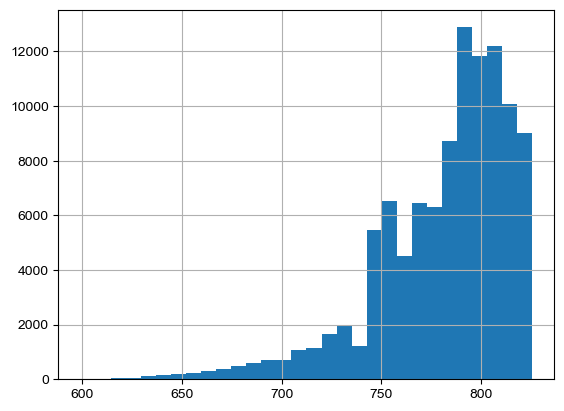

In [122]:
#可视化分数分布
pd_train_score['Score'].hist(bins=30)

In [123]:
#获取完整结果
pd_train_result = pd.concat([y_train,pd_train_score['Score']],axis=1)
score_bin = list(range(400,1000,50))
pd_train_result_bin = pd_train_result
pd_train_result_bin['bin'] = pd.cut(pd_train_result['Score'],score_bin,right=False)
pd_train_result_bin

,SeriousDlqin2yrs,Score,bin
27822,0,791.145294,"[750, 800)"
85202,0,737.675365,"[700, 750)"
42217,0,792.678730,"[750, 800)"
119958,0,817.153779,"[800, 850)"
37678,0,806.495244,"[800, 850)"
...,...,...,...
119879,0,811.221794,"[800, 850)"
103694,0,789.197422,"[750, 800)"
131932,0,801.470809,"[800, 850)"
146867,0,785.439994,"[750, 800)"


In [124]:
#分箱查看各分段违约率
result_table = pd_train_result_bin.groupby('bin')['SeriousDlqin2yrs'].agg([('人数','count'),
                                                            ('违约人数','sum'),
                                                            ('违约率','mean')])
result_table.index.name = '分数区间'
result_table

,人数,违约人数,违约率
分数区间,,,
"[550, 600)",1,1,1.000000
"[600, 650)",481,321,0.667360
"[650, 700)",3023,1518,0.502150
"[700, 750)",12962,2615,0.201744
"[750, 800)",52323,2285,0.043671
"[800, 850)",36210,306,0.008451


### 7.2 KS

In [127]:
#获取分数排序
ks_list = {}
tpr_list = []
fpr_list = []
pd_train_result = pd_train_result.copy()
score_sort = np.sort(pd_train_result['Score'].unique())
for threshold in score_sort:
    pd_train_result['pre'] = (pd_train_result['Score']<threshold).astype(int)
    #Confusion Matrix
    TP = ((pd_train_result['SeriousDlqin2yrs']==1)&(pd_train_result['pre']==1)).sum()
    FN = ((pd_train_result['SeriousDlqin2yrs']==1)&(pd_train_result['pre']==0)).sum()
    FP = ((pd_train_result['SeriousDlqin2yrs']==0)&(pd_train_result['pre']==1)).sum()
    TN = ((pd_train_result['SeriousDlqin2yrs']==0)&(pd_train_result['pre']==0)).sum()
    #TPR & FPR
    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    #收集列表
    tpr_list.append(TPR)
    fpr_list.append(FPR)
    tpr = np.array(tpr_list)
    fpr = np.array(fpr_list)
    #KS
    ks_list[threshold] = TPR - FPR

best_threshold = max(ks_list, key=ks_list.get)
best_ks = ks_list[best_threshold]
print(f'best_ks:{best_ks:.4f}')
print(f'best_threshold:{best_threshold:.2f}')

best_ks:0.5454
best_threshold:764.57


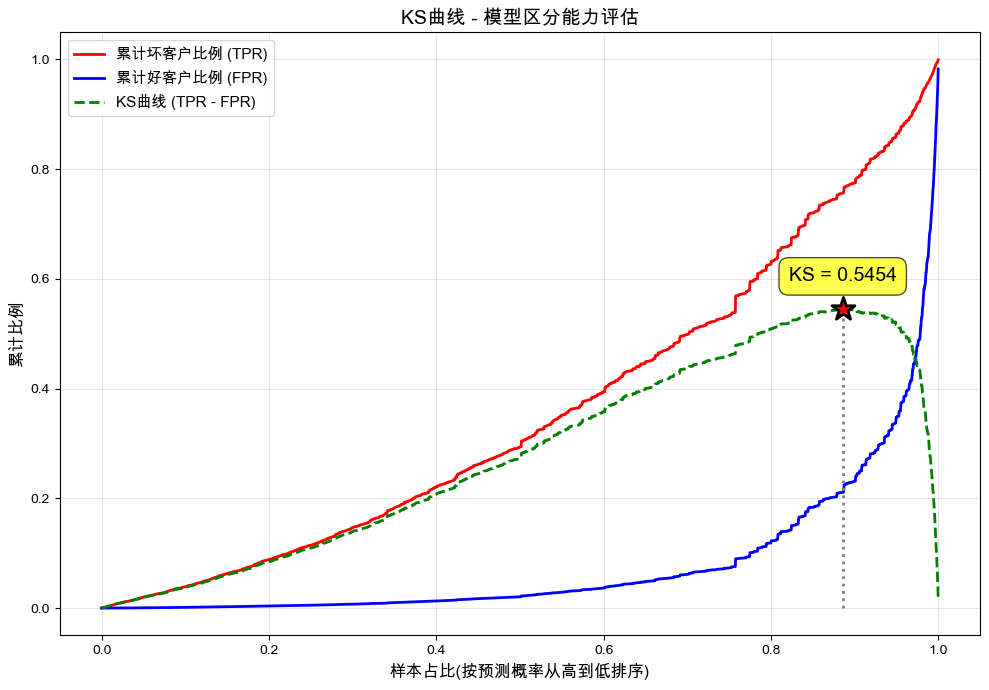

In [128]:
ks_curve = tpr - fpr
ks_index = np.argmax(ks_curve)
ks_value = ks_curve[ks_index]

# 绘图
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 7))

# 绘制累计分布曲线
sample_ratio = np.linspace(0, 1, len(tpr))
plt.plot(sample_ratio, tpr, label='累计坏客户比例 (TPR)', linewidth=2, color='red')
plt.plot(sample_ratio, fpr, label='累计好客户比例 (FPR)', linewidth=2, color='blue')
plt.plot(sample_ratio, ks_curve, label='KS曲线 (TPR - FPR)', 
         linewidth=2, linestyle='--', color='green')

# 标记KS最大值点
ks_point = sample_ratio[ks_index]
plt.scatter(ks_point, ks_value, color='red', s=300, zorder=5, marker='*', 
            edgecolors='black', linewidths=2)
plt.text(ks_point, ks_value + 0.05, f'KS = {ks_value:.4f}', 
         fontsize=14, ha='center', weight='bold', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.vlines(ks_point, 0, ks_value, colors='gray', linestyles='dotted', linewidth=2)
plt.xlabel('样本占比(按预测概率从高到低排序)', fontsize=12)
plt.ylabel('累计比例', fontsize=12)
plt.title('KS曲线 - 模型区分能力评估', fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8.报告

In [ ]:
dict_score

{'RevolvingUtilizationOfUnsecuredLines':                         WOE      score
 bin                                   
 (-0.001, 0.00296]  1.019965  19.226665
 (0.00296, 0.0192]  1.585394  29.885200
 (0.0192, 0.0435]   1.640052  30.915518
 (0.0435, 0.0835]   1.317315  24.831814
 (0.0835, 0.155]    1.035536  19.520188
 (0.155, 0.272]     0.651525  12.281452
 (0.272, 0.446]     0.266354   5.020857
 (0.446, 0.699]    -0.298959  -5.635467
 (0.699, 0.982]    -1.016646 -19.164106
 (0.982, 1.0]      -1.431919 -26.992148,
 'NumberOfTimes90DaysLate':                WOE      score
 bin                          
 [0, 1)    0.370954   5.739490
 [1, 2)   -1.954505 -30.240595
 [2, 3)   -2.654077 -41.064556
 [3, 4)   -2.964001 -45.859766
 [4, 5)   -3.335620 -51.609555
 [5, 6)   -3.125319 -48.355729
 [6, 7)   -3.088055 -47.779172
 [7, 8)   -4.366639 -67.561742
 [8, 9)   -3.379252 -52.284646
 [9, 100) -3.346691 -51.780854,
 'NumberOfTime30-59DaysPastDueNotWorse':                WOE      score
 bin    

In [ ]:
score_table = pd.DataFrame()
for i,v in dict_score.items():
    v = v.copy()
    v.insert(0,'变量',i)
    v.insert(1,'分箱',v.index)
    score_table = pd.concat([score_table,v],ignore_index=True)
print('='*60)
print('信用评分卡报告')
print('='*60)
print(f'基础分: {base_score:.0f}')
print(f'AUC:    {AUC:.4f}')
print(f'KS:     {best_ks:.4f}')
print(f'最优拒贷阈值: {best_threshold:.2f}分')
print()
print('评分卡分箱得分表:')
score_table

信用评分卡报告
基础分: 762
AUC:    0.8515
KS:     0.5454
最优拒贷阈值: 764.57分

评分卡分箱得分表:


,变量,分箱,WOE,score
0,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.00296]",1.019965,19.226665
1,RevolvingUtilizationOfUnsecuredLines,"(0.00296, 0.0192]",1.585394,29.885200
2,RevolvingUtilizationOfUnsecuredLines,"(0.0192, 0.0435]",1.640052,30.915518
3,RevolvingUtilizationOfUnsecuredLines,"(0.0435, 0.0835]",1.317315,24.831814
4,RevolvingUtilizationOfUnsecuredLines,"(0.0835, 0.155]",1.035536,19.520188
5,RevolvingUtilizationOfUnsecuredLines,"(0.155, 0.272]",0.651525,12.281452
6,RevolvingUtilizationOfUnsecuredLines,"(0.272, 0.446]",0.266354,5.020857
7,RevolvingUtilizationOfUnsecuredLines,"(0.446, 0.699]",-0.298959,-5.635467
8,RevolvingUtilizationOfUnsecuredLines,"(0.699, 0.982]",-1.016646,-19.164106
9,RevolvingUtilizationOfUnsecuredLines,"(0.982, 1.0]",-1.431919,-26.992148
